<a href="https://colab.research.google.com/github/PoojaKumariR-student/Bank-Fraud-Detection-Using-Machine-Learning-in-Google-Colab/blob/main/Bank_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Loading the libraries**

In [ ]:
import pandas as pd
import numpy as np

# **Step 1 - Loading the dataset**

In [ ]:
df = pd.read_csv("/content/Banking_Fraud_Dataset.csv")
df

,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Type,Transaction_Location,Transaction_Time,Device_Used,Account_Age,Credit_Score,Previous_Fraud,Is_Fraud
0,T1,C2539,8527.58,Deposit,"Hughesmouth, Mongolia",2025-01-20 03:17:34,Mobile,16,740,0,0
1,T2,C5318,9275.82,Deposit,"Huntville, Saint Pierre and Miquelon",2025-01-03 18:08:56,Web,5,848,0,1
2,T3,C8262,2202.49,Online Payment,"Patriciashire, Iceland",2025-01-24 05:54:01,ATM,2,616,1,1
3,T4,C3865,9352.32,Deposit,"Port Timothymouth, Palau",2025-01-19 01:15:30,ATM,9,437,1,0
4,T5,C7248,2081.75,Online Payment,"Lake Stevenfurt, Mauritius",2025-01-08 18:06:13,ATM,15,494,0,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,T9996,C2340,3678.03,Online Payment,"Port Matthew, Malawi",2025-01-14 05:47:08,Web,1,439,1,1
9996,T9997,C6185,6041.40,Transfer,"Lanceville, Swaziland",2025-01-08 04:40:34,POS Terminal,4,738,1,1
9997,T9998,C6114,4755.10,Online Payment,"North Scottmouth, Guinea-Bissau",2025-01-17 05:00:54,POS Terminal,18,649,1,1
9998,T9999,C4483,1649.96,Deposit,"North Miranda, Estonia",2025-01-23 09:44:47,POS Terminal,10,838,1,1


# Step 2 -**Understanding** **the** **dataset**

In [ ]:
df.head()

,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Type,Transaction_Location,Transaction_Time,Device_Used,Account_Age,Credit_Score,Previous_Fraud,Is_Fraud
0,T1,C2539,8527.58,Deposit,"Hughesmouth, Mongolia",2025-01-20 03:17:34,Mobile,16,740,0,0
1,T2,C5318,9275.82,Deposit,"Huntville, Saint Pierre and Miquelon",2025-01-03 18:08:56,Web,5,848,0,1
2,T3,C8262,2202.49,Online Payment,"Patriciashire, Iceland",2025-01-24 05:54:01,ATM,2,616,1,1
3,T4,C3865,9352.32,Deposit,"Port Timothymouth, Palau",2025-01-19 01:15:30,ATM,9,437,1,0
4,T5,C7248,2081.75,Online Payment,"Lake Stevenfurt, Mauritius",2025-01-08 18:06:13,ATM,15,494,0,0


In [ ]:
df.tail()

,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Type,Transaction_Location,Transaction_Time,Device_Used,Account_Age,Credit_Score,Previous_Fraud,Is_Fraud
9995,T9996,C2340,3678.03,Online Payment,"Port Matthew, Malawi",2025-01-14 05:47:08,Web,1,439,1,1
9996,T9997,C6185,6041.40,Transfer,"Lanceville, Swaziland",2025-01-08 04:40:34,POS Terminal,4,738,1,1
9997,T9998,C6114,4755.10,Online Payment,"North Scottmouth, Guinea-Bissau",2025-01-17 05:00:54,POS Terminal,18,649,1,1
9998,T9999,C4483,1649.96,Deposit,"North Miranda, Estonia",2025-01-23 09:44:47,POS Terminal,10,838,1,1
9999,T10000,C1171,6232.83,Deposit,"Gilesfort, Argentina",2025-01-08 03:30:27,Mobile,16,572,0,1


In [ ]:
df.shape

(10000, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Transaction_ID        10000 non-null  object 
 1   Customer_ID           10000 non-null  object 
 2   Transaction_Amount    10000 non-null  float64
 3   Transaction_Type      10000 non-null  object 
 4   Transaction_Location  10000 non-null  object 
 5   Transaction_Time      10000 non-null  object 
 6   Device_Used           10000 non-null  object 
 7   Account_Age           10000 non-null  int64  
 8   Credit_Score          10000 non-null  int64  
 9   Previous_Fraud        10000 non-null  int64  
 10  Is_Fraud              10000 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 859.5+ KB


In [ ]:
df.describe()

,Transaction_Amount,Account_Age,Credit_Score,Previous_Fraud,Is_Fraud
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,4997.492361,10.646900,578.66280,0.501700,0.283800
std,2914.985459,5.760186,158.73193,0.500022,0.450863
min,10.890000,1.000000,300.00000,0.000000,0.000000
25%,2469.642500,6.000000,442.00000,0.000000,0.000000
50%,4985.325000,11.000000,581.00000,1.000000,0.000000
75%,7557.885000,16.000000,715.00000,1.000000,1.000000
max,9999.290000,20.000000,850.00000,1.000000,1.000000


In [ ]:
df.columns

Index(['Transaction_ID', 'Customer_ID', 'Transaction_Amount',
       'Transaction_Type', 'Transaction_Location', 'Transaction_Time',
       'Device_Used', 'Account_Age', 'Credit_Score', 'Previous_Fraud',
       'Is_Fraud'],
      dtype='object')

In [ ]:
df["Is_Fraud"].value_counts()

,count
Is_Fraud,
0,7162
1,2838


In [ ]:
df["Previous_Fraud"].value_counts()

,count
Previous_Fraud,
1,5017
0,4983


# **Step 3 - Cleaning the data**

In [ ]:
df.isnull().sum()

,0
Transaction_ID,0
Customer_ID,0
Transaction_Amount,0
Transaction_Type,0
Transaction_Location,0
Transaction_Time,0
Device_Used,0
Account_Age,0
Credit_Score,0
Previous_Fraud,0


In [ ]:
df.drop_duplicates()

,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Type,Transaction_Location,Transaction_Time,Device_Used,Account_Age,Credit_Score,Previous_Fraud,Is_Fraud
0,T1,C2539,8527.58,Deposit,"Hughesmouth, Mongolia",2025-01-20 03:17:34,Mobile,16,740,0,0
1,T2,C5318,9275.82,Deposit,"Huntville, Saint Pierre and Miquelon",2025-01-03 18:08:56,Web,5,848,0,1
2,T3,C8262,2202.49,Online Payment,"Patriciashire, Iceland",2025-01-24 05:54:01,ATM,2,616,1,1
3,T4,C3865,9352.32,Deposit,"Port Timothymouth, Palau",2025-01-19 01:15:30,ATM,9,437,1,0
4,T5,C7248,2081.75,Online Payment,"Lake Stevenfurt, Mauritius",2025-01-08 18:06:13,ATM,15,494,0,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,T9996,C2340,3678.03,Online Payment,"Port Matthew, Malawi",2025-01-14 05:47:08,Web,1,439,1,1
9996,T9997,C6185,6041.40,Transfer,"Lanceville, Swaziland",2025-01-08 04:40:34,POS Terminal,4,738,1,1
9997,T9998,C6114,4755.10,Online Payment,"North Scottmouth, Guinea-Bissau",2025-01-17 05:00:54,POS Terminal,18,649,1,1
9998,T9999,C4483,1649.96,Deposit,"North Miranda, Estonia",2025-01-23 09:44:47,POS Terminal,10,838,1,1


In [ ]:
df = df.drop(columns ="Account_Age")

In [ ]:
df = df.drop(columns = "Credit_Score")

In [ ]:
df.dropna()

,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Type,Transaction_Location,Transaction_Time,Device_Used,Previous_Fraud,Is_Fraud
0,T1,C2539,8527.58,Deposit,"Hughesmouth, Mongolia",2025-01-20 03:17:34,Mobile,0,0
1,T2,C5318,9275.82,Deposit,"Huntville, Saint Pierre and Miquelon",2025-01-03 18:08:56,Web,0,1
2,T3,C8262,2202.49,Online Payment,"Patriciashire, Iceland",2025-01-24 05:54:01,ATM,1,1
3,T4,C3865,9352.32,Deposit,"Port Timothymouth, Palau",2025-01-19 01:15:30,ATM,1,0
4,T5,C7248,2081.75,Online Payment,"Lake Stevenfurt, Mauritius",2025-01-08 18:06:13,ATM,0,0
...,...,...,...,...,...,...,...,...,...
9995,T9996,C2340,3678.03,Online Payment,"Port Matthew, Malawi",2025-01-14 05:47:08,Web,1,1
9996,T9997,C6185,6041.40,Transfer,"Lanceville, Swaziland",2025-01-08 04:40:34,POS Terminal,1,1
9997,T9998,C6114,4755.10,Online Payment,"North Scottmouth, Guinea-Bissau",2025-01-17 05:00:54,POS Terminal,1,1
9998,T9999,C4483,1649.96,Deposit,"North Miranda, Estonia",2025-01-23 09:44:47,POS Terminal,1,1


In [ ]:
df

,Transaction_ID,Customer_ID,Transaction_Amount,Transaction_Type,Transaction_Location,Transaction_Time,Device_Used,Previous_Fraud,Is_Fraud
0,T1,C2539,8527.58,Deposit,"Hughesmouth, Mongolia",2025-01-20 03:17:34,Mobile,0,0
1,T2,C5318,9275.82,Deposit,"Huntville, Saint Pierre and Miquelon",2025-01-03 18:08:56,Web,0,1
2,T3,C8262,2202.49,Online Payment,"Patriciashire, Iceland",2025-01-24 05:54:01,ATM,1,1
3,T4,C3865,9352.32,Deposit,"Port Timothymouth, Palau",2025-01-19 01:15:30,ATM,1,0
4,T5,C7248,2081.75,Online Payment,"Lake Stevenfurt, Mauritius",2025-01-08 18:06:13,ATM,0,0
...,...,...,...,...,...,...,...,...,...
9995,T9996,C2340,3678.03,Online Payment,"Port Matthew, Malawi",2025-01-14 05:47:08,Web,1,1
9996,T9997,C6185,6041.40,Transfer,"Lanceville, Swaziland",2025-01-08 04:40:34,POS Terminal,1,1
9997,T9998,C6114,4755.10,Online Payment,"North Scottmouth, Guinea-Bissau",2025-01-17 05:00:54,POS Terminal,1,1
9998,T9999,C4483,1649.96,Deposit,"North Miranda, Estonia",2025-01-23 09:44:47,POS Terminal,1,1


In [ ]:
df.shape

(10000, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Transaction_ID        10000 non-null  object 
 1   Customer_ID           10000 non-null  object 
 2   Transaction_Amount    10000 non-null  float64
 3   Transaction_Type      10000 non-null  object 
 4   Transaction_Location  10000 non-null  object 
 5   Transaction_Time      10000 non-null  object 
 6   Device_Used           10000 non-null  object 
 7   Previous_Fraud        10000 non-null  int64  
 8   Is_Fraud              10000 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 703.3+ KB


In [ ]:
df.describe()

,Transaction_Amount,Previous_Fraud,Is_Fraud
count,10000.000000,10000.000000,10000.000000
mean,4997.492361,0.501700,0.283800
std,2914.985459,0.500022,0.450863
min,10.890000,0.000000,0.000000
25%,2469.642500,0.000000,0.000000
50%,4985.325000,1.000000,0.000000
75%,7557.885000,1.000000,1.000000
max,9999.290000,1.000000,1.000000


# **Step 4 - Data Visualization**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

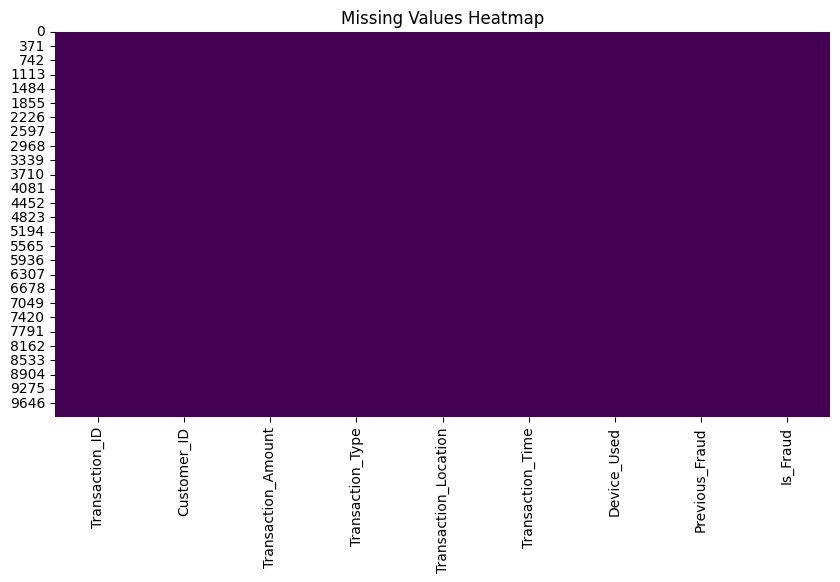

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

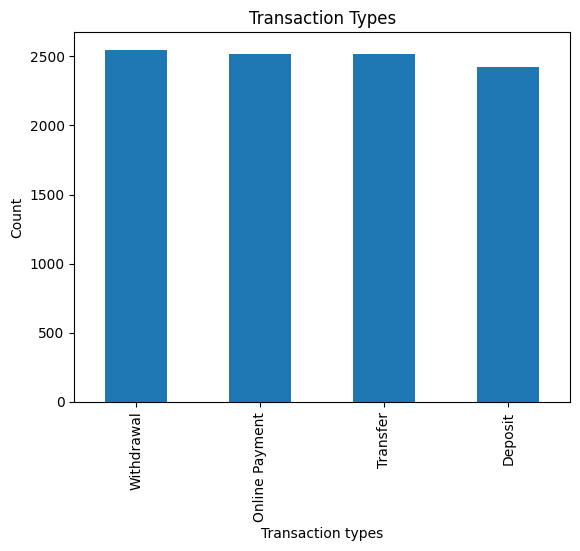

In [ ]:
df["Transaction_Type"].value_counts().plot(kind="bar", title="Transaction Types")
plt.xlabel("Transaction types")
plt.ylabel("Count")
plt.show()

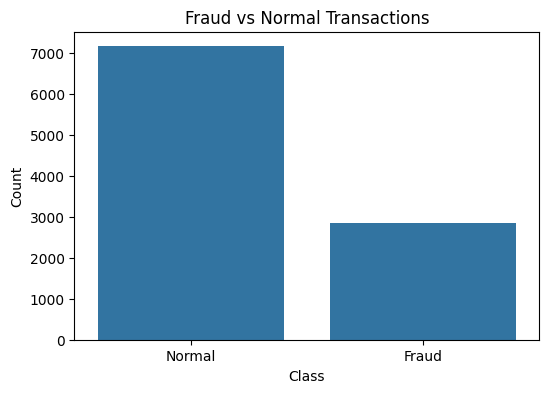

In [ ]:
count_classes = df['Is_Fraud'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=count_classes.index, y=count_classes.values)

plt.title('Fraud vs Normal Transactions')
plt.xlabel('Class')
plt.ylabel('Count')

plt.xticks([0,1], ['Normal', 'Fraud'])
plt.show()

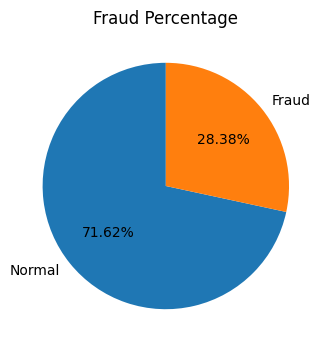

In [ ]:
fraud_counts = df['Is_Fraud'].value_counts()

labels = ['Normal', 'Fraud']

plt.figure(figsize=(4,4))

plt.pie(
    fraud_counts,
    labels=labels,
    autopct='%1.2f%%',
    startangle=90
)

plt.title('Fraud Percentage')
plt.show()

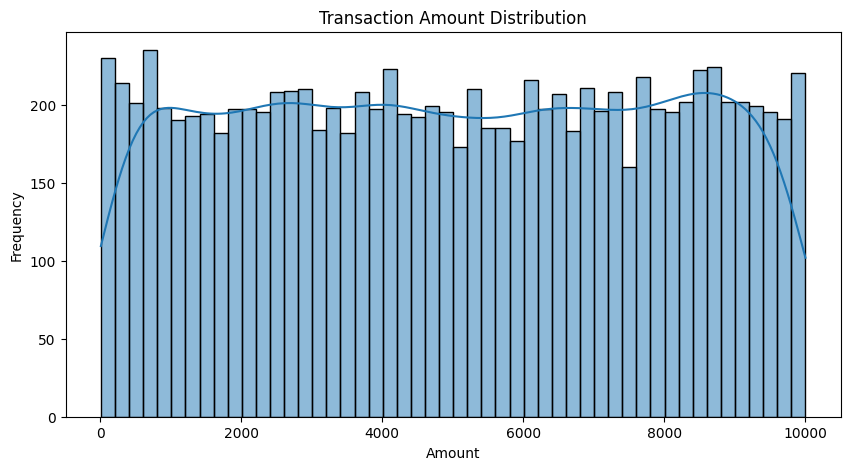

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df['Transaction_Amount'], bins=50, kde=True)

plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Frequency')

plt.show()

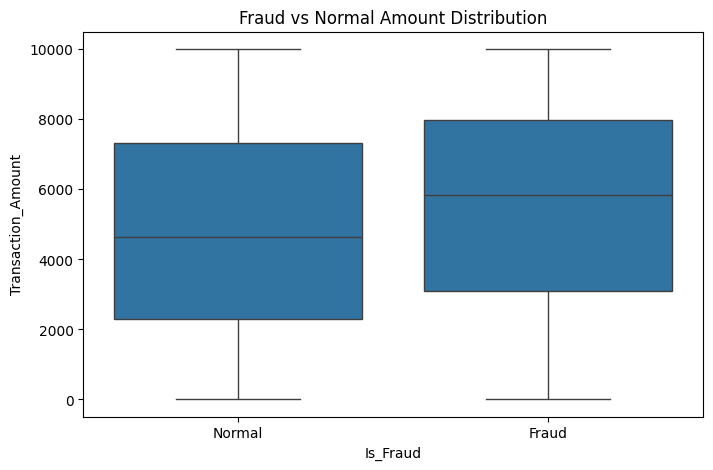

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Is_Fraud', y='Transaction_Amount', data=df)

plt.title('Fraud vs Normal Amount Distribution')
plt.xticks([0,1], ['Normal', 'Fraud'])
plt.show()

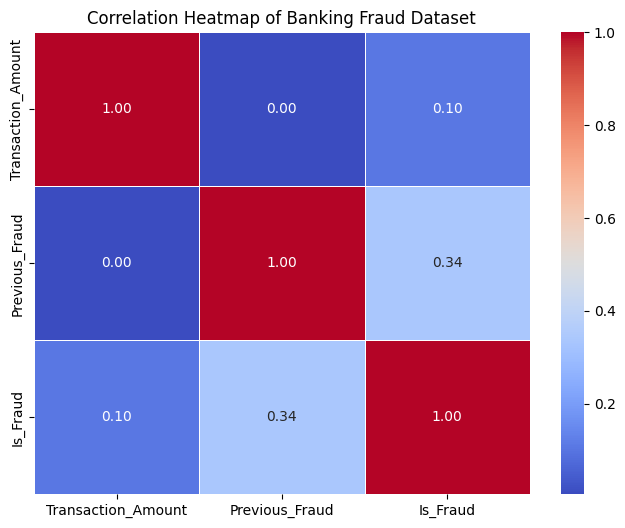

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Banking Fraud Dataset')
plt.show()

# **Step 5 - Model Training and Evaluation**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [ ]:
df.dtypes

,0
Transaction_ID,object
Customer_ID,object
Transaction_Amount,float64
Transaction_Type,object
Transaction_Location,object
Transaction_Time,object
Device_Used,object
Previous_Fraud,int64
Is_Fraud,int64


In [ ]:
# Create encoder
le = LabelEncoder()

# Convert all object columns
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

In [ ]:
df.dtypes

,0
Transaction_ID,int64
Customer_ID,int64
Transaction_Amount,float64
Transaction_Type,int64
Transaction_Location,int64
Transaction_Time,int64
Device_Used,int64
Previous_Fraud,int64
Is_Fraud,int64


In [ ]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

numeric_columns = numeric_columns.drop('Is_Fraud')

scaler = StandardScaler()

df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

In [ ]:
X = df.drop('Is_Fraud', axis=1)

y = df['Is_Fraud']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
fraud = len(y_train[y_train == 1])

normal = len(y_train[y_train == 0])

scale_weight = normal / fraud

print(scale_weight)

2.5242290748898677


# XGBoost

In [ ]:
!pip install xgboost
!pip install shap
!pip install tensorflow

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_weight,
    eval_metric='logloss',
    random_state=42
)

In [ ]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred = xgb_model.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.70      0.75      1432
           1       0.44      0.60      0.51       568

    accuracy                           0.67      2000
   macro avg       0.63      0.65      0.63      2000
weighted avg       0.71      0.67      0.68      2000



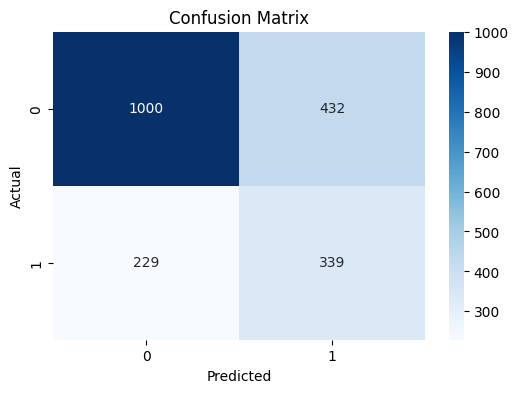

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6695


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

In [ ]:
input_dim = X_train.shape[1]

encoding_dim = 14

input_layer = Input(shape=(input_dim,))

encoder = Dense(32, activation='relu')(input_layer)

encoder = Dense(encoding_dim, activation='relu')(encoder)

decoder = Dense(32, activation='relu')(encoder)

decoder = Dense(input_dim, activation='sigmoid')(decoder)

autoencoder = Model(
    inputs=input_layer,
    outputs=decoder
)

In [ ]:
autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

In [ ]:
X_train_normal = X_train[y_train == 0]

autoencoder.fit(
    X_train_normal,
    X_train_normal,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.1591 - val_loss: 0.9781
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8959 - val_loss: 0.8267
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7845 - val_loss: 0.7365
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7016 - val_loss: 0.6477
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6142 - val_loss: 0.5822
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5742 - val_loss: 0.5643
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5631 - val_loss: 0.5588
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5589 - val_loss: 0.5561
Epoch 9/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5568 - val_loss: 0.5546
Epoch 10/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5555 - val_loss: 0.5535
Epoch 11/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5546 - val_loss: 0.5529
Epoch 12/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5540 - val_lo

In [ ]:
reconstructions = autoencoder.predict(X_test)

mse = np.mean(
    np.power(X_test - reconstructions, 2),
    axis=1
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


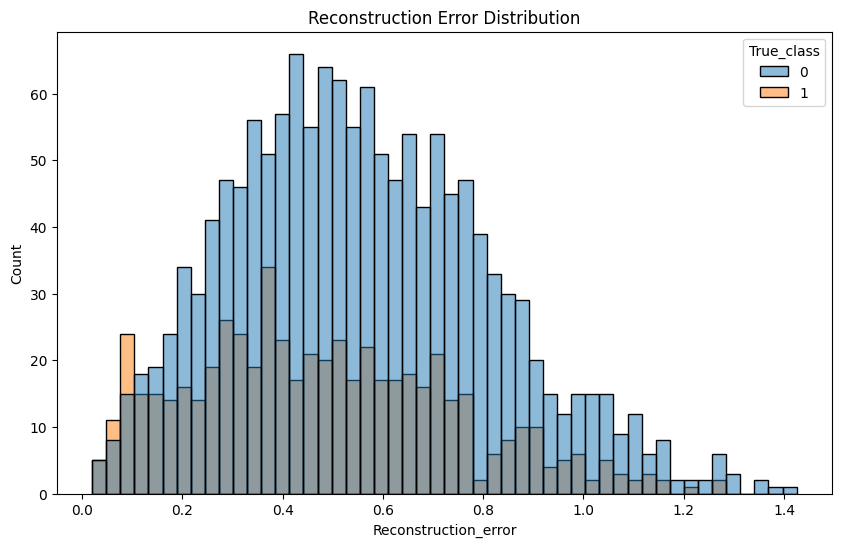

In [ ]:
error_df = pd.DataFrame({
    'Reconstruction_error': mse,
    'True_class': y_test
})

plt.figure(figsize=(10,6))

sns.histplot(
    data=error_df,
    x='Reconstruction_error',
    hue='True_class',
    bins=50
)

plt.title('Reconstruction Error Distribution')

plt.show()

In [ ]:
threshold = np.percentile(mse, 95)

anomaly_predictions = (mse > threshold).astype(int)

In [ ]:
import shap

In [ ]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

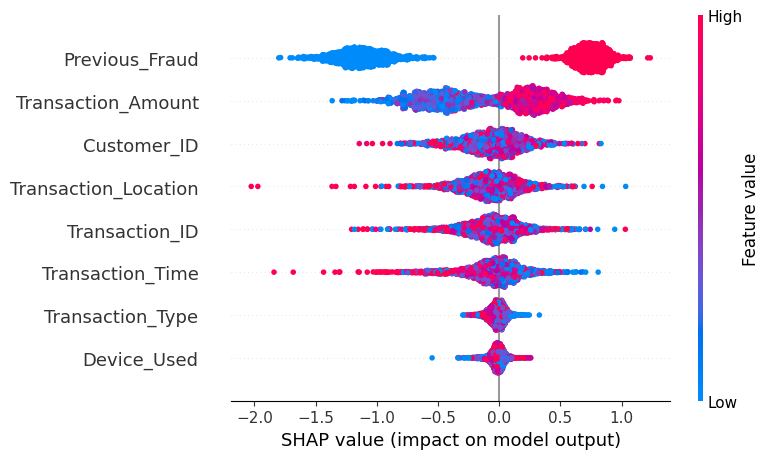

In [ ]:
shap.summary_plot(
    shap_values,
    X_test
)

## Customers with previous fraud history are more likely to commit fraud again.

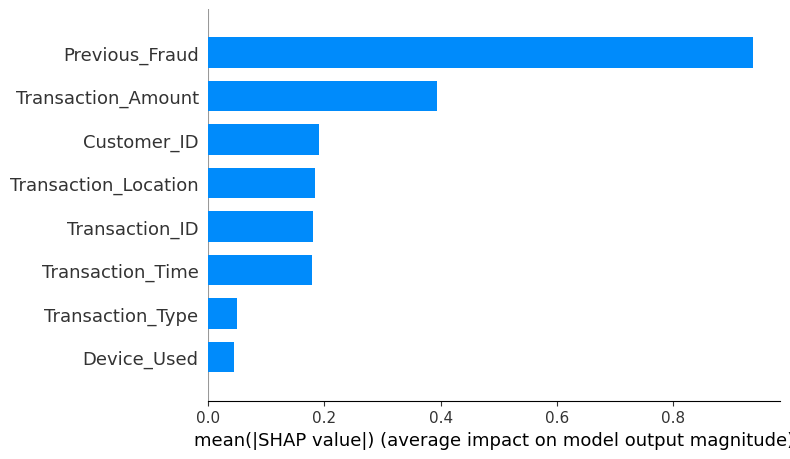

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar'
)